# Stage 1: Define Prediction Grid

Creates cluster-sized prediction points across 10 target provinces + NCR.
Uses **PSGC shapefiles** from [altcoder/philippines-psgc-shapefiles](https://github.com/altcoder/philippines-psgc-shapefiles) which have the updated Maguindanao del Norte / del Sur split.

**Target areas (5 lowest poverty incidence):**
- Ilocos Norte (0.3%), Pampanga (1.0%), Benguet (2.5%), Kalinga (2.6%), Aklan (3.1%)

**Target areas (5 highest poverty incidence):**
- Zamboanga del Norte (37.7%), Basilan (33.7%), Tawi-Tawi (32.3%), Maguindanao del Sur (32.1%), Davao Oriental (29.1%)

**Plus:** NCR

**Output:** `prediction_points.csv`

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')
print(f"GeoPandas: {gpd.__version__}")

GeoPandas: 1.1.2


In [2]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

# PSGC shapefiles from: https://github.com/altcoder/philippines-psgc-shapefiles
PSGC_DIR = '/Users/ruben/Desktop/Thesis/2025Data/'
MUNI_SHP  = f'{PSGC_DIR}/PH_Adm3_MuniCities.shp'

# DHS cluster shapefile
DHS_SHP = '/Users/ruben/Desktop/Thesis/TrainingData/PH_DHS_GPS/PHGE81FL/PHGE81FL.shp'

# Output — must point to the SAME directory as the existing prediction_points.csv
OUTPUT_DIR = '/Users/ruben/Desktop/Thesis/2025Data/baguio/input'
EXISTING_CSV = f'{OUTPUT_DIR}/prediction_points.csv'

os.makedirs(OUTPUT_DIR, exist_ok=True)

GRID_RURAL_M = 5000
GRID_URBAN_M = 2000
PH_CRS = 'EPSG:32651'

# ── APPEND MODE ──────────────────────────────────────────────────────────
# List ONLY the new provinces you want to add here.
# Provinces already in EXISTING_CSV are automatically detected and skipped,
# so existing PointIDs are never changed.
#
# To do a full rebuild from scratch, delete EXISTING_CSV and list ALL
# target provinces here — the notebook will behave as it did originally.
NEW_PROVINCES = [
    # Add new province names here, e.g.:
    # 'Cebu',
    # 'Leyte',
    #'Bulacan'
    'City of Baguio'
]

# All provinces ever processed (existing + new).
# Do NOT remove provinces that are already in EXISTING_CSV from this list.
ALL_PROVINCE_PREFIXES = {
    'Ilocos Norte'       : '1028',
    'Pampanga'           : '3054',
    'Benguet'            : '14011',
    'Kalinga'            : '14032',
    'Aklan'              : '6004',
    'Zamboanga del Norte': '9072',
    'Basilan'            : '19007',
    'Tawi-Tawi'          : '19070',
    'Maguindanao del Sur': '19088',
    'Davao Oriental'     : '11025',
    'NCR'                : '13',
    'Bataan'             : '3008',
    'Zambales'           : '3071',
    'Occidental Mindoro' : '17051',
    'Oriental Mindoro'   : '17052',
    'Bulacan'            : '3014',
    # Add new province → PSGC prefix entries here:
    # 'Cebu'             : '7022',
    'City of Baguio'   : '14303'
}

POVERTY_RATES = {
    'Ilocos Norte': 0.3, 'Pampanga': 1.0, 'Benguet': 2.5,
    'Kalinga': 2.6, 'Aklan': 3.1, 'Zamboanga del Norte': 37.7,
    'Basilan': 33.7, 'Tawi-Tawi': 32.3,
    'Maguindanao del Sur': 32.1, 'Davao Oriental': 29.1,
    'Bataan': 6.6, 'Oriental Mindoro': 14.1,
    'Occidental Mindoro': 20.6, 'Zambales': 11.8,
    'NCR': 1.1, 'Bulacan': 6.0,
    # Add poverty rates for new provinces here:
    # 'Cebu': 9.0,
}

NCR_REGION_NAME = 'NCR'
SEED = 42
np.random.seed(SEED)

# ── Detect append vs full-build mode ─────────────────────────────────────
if os.path.exists(EXISTING_CSV):
    df_existing = pd.read_csv(EXISTING_CSV)
    EXISTING_PROVINCES = set(df_existing['Province'].unique())
    NEXT_POINT_ID = int(df_existing['PointID'].max()) + 1
    # Build only the provinces not already covered.
    # If NEW_PROVINCES is empty the notebook stops after this cell with a
    # message — add province names to NEW_PROVINCES above to proceed.
    TARGET_PROVINCES = [p for p in NEW_PROVINCES if p not in EXISTING_PROVINCES]
    APPEND_MODE = True
    print(f"APPEND MODE — existing CSV has {len(df_existing)} points "
          f"across {len(EXISTING_PROVINCES)} provinces.")
    print(f"Next PointID starts at: {NEXT_POINT_ID}")
    if not TARGET_PROVINCES:
        print("\nNo new provinces to process. Add province names to NEW_PROVINCES.")
    else:
        print(f"\nNew provinces to generate: {TARGET_PROVINCES}")
else:
    df_existing = None
    EXISTING_PROVINCES = set()
    NEXT_POINT_ID = 1
    # Full build — use all defined provinces
    TARGET_PROVINCES = list(ALL_PROVINCE_PREFIXES.keys())
    APPEND_MODE = False
    print(f"FULL BUILD MODE — no existing CSV found.")
    print(f"Generating {len(TARGET_PROVINCES)} provinces from scratch.")


APPEND MODE — existing CSV has 1989 points across 16 provinces.
Next PointID starts at: 1996

New provinces to generate: ['City of Baguio']


### Append guard
The cells below are skipped automatically if `TARGET_PROVINCES` is empty 
(i.e., all requested provinces are already in the existing CSV).

In [3]:
# ============================================================
# 2. LOAD MUNICIPALITIES AND FILTER VIA P-CODE DICTIONARY
# ============================================================

if APPEND_MODE and not TARGET_PROVINCES:
    print("Nothing to process. Add provinces to NEW_PROVINCES in cell 1.")
else:
    OLONGAPO_PREFIX = '3314'
    ANGELES_PREFIX  = '3301'
    

    print("Loading PSGC municipality boundaries...")
    gdf_muni = gpd.read_file(MUNI_SHP)
    gdf_muni.columns = gdf_muni.columns.str.lower()
    gdf_muni['psgc_code'] = (
        gdf_muni['psgc_code'].astype(str).str.replace('.0', '', regex=False)
    )

    gdf_muni['Province']     = None
    gdf_muni['Municipality'] = gdf_muni['name']

    print("Applying Province labels via PSGC prefixes...")
    # Use ALL_PROVINCE_PREFIXES so the shapefile lookup always covers
    # every province, even if we are only generating a subset.
    for prov, prefix in ALL_PROVINCE_PREFIXES.items():
        mask = gdf_muni['psgc_code'].str.startswith(prefix)
        gdf_muni.loc[mask, 'Province'] = prov

    olongapo_mask = gdf_muni['psgc_code'].str.startswith(OLONGAPO_PREFIX)
    gdf_muni.loc[olongapo_mask, 'Province'] = 'Zambales'

    angeles_mask = gdf_muni['psgc_code'].str.startswith(ANGELES_PREFIX)
    gdf_muni.loc[angeles_mask, 'Province'] = 'Pampanga'

    URBAN_HCUS = {'City of Olongapo', 'City of Angeles'}
    gdf_muni['is_urban_huc'] = gdf_muni['name'].isin(URBAN_HCUS)

    # Filter to ONLY the provinces we need to generate this run
    gdf_target = gdf_muni[gdf_muni['Province'].isin(TARGET_PROVINCES)].copy()
    gdf_target['is_ncr'] = gdf_target['Province'] == 'NCR'

    print(f"\nFiltered to {len(gdf_target)} municipalities across:")
    for prov, count in gdf_target['Province'].value_counts().items():
        print(f"  {prov}: {count} municipalities")

    gdf_target = gdf_target.to_crs(PH_CRS)
    print(f"\nReprojected to {PH_CRS}")

    COL_PROVINCE = 'Province'
    COL_MUNI     = 'Municipality'
    COL_PCODE    = 'psgc_code'
    COL_REGION   = 'adm1_pcode'


Loading PSGC municipality boundaries...
Applying Province labels via PSGC prefixes...

Filtered to 1 municipalities across:
  City of Baguio: 1 municipalities

Reprojected to EPSG:32651


In [4]:
# ============================================================
# 3. CREATE GRID POINTS
# ============================================================

if APPEND_MODE and not TARGET_PROVINCES:
    print("Skipped — nothing to process.")
else:
    def generate_grid_within_polygon(polygon, spacing_m):
        minx, miny, maxx, maxy = polygon.bounds
        xs = np.arange(minx, maxx, spacing_m)
        ys = np.arange(miny, maxy, spacing_m)
        points = []
        for x in xs:
            for y in ys:
                pt = Point(x, y)
                if polygon.contains(pt):
                    points.append(pt)
        return points

    print("Generating prediction grid...")
    all_points = []
    # Start from NEXT_POINT_ID so appended points never collide with
    # existing IDs.  On a full build NEXT_POINT_ID == 1.
    point_id = NEXT_POINT_ID

    for idx, row in gdf_target.iterrows():
        municipality = row[COL_MUNI]
        province     = row[COL_PROVINCE]
        region       = row[COL_REGION]
        is_ncr       = row['is_ncr']
        pcode        = row.get(COL_PCODE, None)

        is_urban = row['is_ncr'] or row.get('is_urban_huc', False)
        spacing  = GRID_URBAN_M if is_urban else GRID_RURAL_M
        polygon  = row.geometry
        if polygon is None or polygon.is_empty:
            continue

        sub_polys = list(polygon.geoms) if polygon.geom_type == 'MultiPolygon' else [polygon]

        muni_points = []
        for poly in sub_polys:
            muni_points.extend(generate_grid_within_polygon(poly, spacing))

        for pt in muni_points:
            all_points.append({
                'PointID'     : point_id,
                'Municipality': municipality,
                'Province'    : province,
                'Region'      : region,
                'PSGC'        : pcode,
                'is_ncr'      : is_ncr,
                'is_urban_huc': row.get('is_urban_huc', False),
                'dhs_urban'   : None,
                'geometry'    : pt,
                'source'      : 'grid',
                'DHSCLUST'    : None,
            })
            point_id += 1

    gdf_points = gpd.GeoDataFrame(all_points, crs=PH_CRS)
    print(f"\nTotal grid points: {len(gdf_points)}")
    for prov, count in gdf_points['Province'].value_counts().items():
        print(f"  {prov}: {count}")


Generating prediction grid...

Total grid points: 1
  City of Baguio: 1


In [5]:
# ============================================================
# 3B. CHECK DENSITY
# ============================================================

muni_counts = gdf_points.groupby(
    ['Province', 'Municipality']
).size().reset_index(name='n_points')
print("Points per municipality (top 20):")
print(muni_counts.sort_values('n_points', ascending=False).head(20).to_string(index=False))
print(f"\nMunicipalities with 1 point: {(muni_counts['n_points'] == 1).sum()}")
print(f"Total: {len(gdf_points)}")

Points per municipality (top 20):
      Province   Municipality  n_points
City of Baguio City of Baguio         1

Municipalities with 1 point: 1
Total: 1


In [6]:
# ============================================================
# 3C. CLIP GRID TO TRUE LANDMASS
# ============================================================

print("Loading true landmass boundaries...")
# UPDATE THIS PATH to wherever you saved the National/ADM0 shapefile
ADM0_SHP = '/Users/ruben/Desktop/Thesis/2025Data/gadm41_PHL_shp/gadm41_PHL_0.shp' 

ph_landmass = gpd.read_file(ADM0_SHP).to_crs(PH_CRS)

print("Clipping ocean points...")
print(f"Points before clipping: {len(gdf_points)}")

# Keep ONLY the prediction points that physically intersect the land polygon
gdf_points = gpd.sjoin(gdf_points, ph_landmass[['geometry']], how='inner', predicate='intersects')

# Clean up the extra index column created by the spatial join
gdf_points = gdf_points.drop(columns=['index_right'], errors='ignore')

print(f"Points after clipping: {len(gdf_points)}")

# Quick density check update
muni_counts_clipped = gdf_points.groupby(['Province', 'Municipality']).size().reset_index(name='n_points')
print("\nNew points per municipality (top 5):")
print(muni_counts_clipped.sort_values('n_points', ascending=False).head(5).to_string(index=False))

Loading true landmass boundaries...
Clipping ocean points...
Points before clipping: 1
Points after clipping: 1

New points per municipality (top 5):
      Province   Municipality  n_points
City of Baguio City of Baguio         1


In [7]:
# ============================================================
# 4. ADD DHS CLUSTERS
# ============================================================

print("Loading DHS cluster locations...")
gdf_dhs = gpd.read_file(DHS_SHP).to_crs(PH_CRS)
print(f"Total DHS clusters: {len(gdf_dhs)}")

dhs_in_target = gpd.sjoin(
    gdf_dhs,
    gdf_target[[COL_PROVINCE, COL_MUNI, COL_REGION, 'is_ncr', 'geometry']],
    how='inner', predicate='within'
)
print(f"DHS clusters inside target areas: {len(dhs_in_target)}")

dhs_points = []
for idx, row in dhs_in_target.iterrows():
    dhs_points.append({
        'PointID': point_id,
        'Municipality': row[COL_MUNI],
        'Province': row[COL_PROVINCE],
        'Region': row[COL_REGION],
        'PSGC': None,
        'is_ncr': row['is_ncr'],
        'is_urban_huc': row.get('is_urban_huc', False),
        'dhs_urban'   : str(row.get('URBAN_RURA', 'R')).strip().upper(),
        'geometry': row.geometry,
        'source': 'DHS',
        'DHSCLUST': int(row['DHSCLUST']) if 'DHSCLUST' in row else None
    })
    point_id += 1

gdf_points['source'] = 'grid'
gdf_points['DHSCLUST'] = None

if len(dhs_points) > 0:
    gdf_dhs_pts = gpd.GeoDataFrame(dhs_points, crs=PH_CRS)
    gdf_all = pd.concat([gdf_points, gdf_dhs_pts], ignore_index=True)
    gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)
else:
    gdf_all = gdf_points.copy()

print(f"Total (grid + DHS): {len(gdf_all)}")
print(f"  Grid: {(gdf_all['source'] == 'grid').sum()}")
print(f"  DHS:  {(gdf_all['source'] == 'DHS').sum()}")

Loading DHS cluster locations...
Total DHS clusters: 1247
DHS clusters inside target areas: 8
Total (grid + DHS): 9
  Grid: 1
  DHS:  8


In [8]:
# ============================================================
# 4B. REMOVE GRID POINTS TOO CLOSE TO DHS
# ============================================================

MIN_DISTANCE_M = 2000
dhs_mask = gdf_all['source'] == 'DHS'
grid_mask = gdf_all['source'] == 'grid'

if dhs_mask.sum() > 0:
    from shapely.ops import unary_union
    dhs_buffer = unary_union(gdf_all[dhs_mask].geometry.buffer(MIN_DISTANCE_M))
    too_close = gdf_all[grid_mask].geometry.within(dhs_buffer)
    n_removed = too_close.sum()
    keep_grid = gdf_all[grid_mask][~too_close]
    gdf_all = pd.concat([keep_grid, gdf_all[dhs_mask]], ignore_index=True)
    gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)
    print(f"Removed {n_removed} grid points within {MIN_DISTANCE_M}m of DHS.")

print(f"Final: {len(gdf_all)}")

Removed 1 grid points within 2000m of DHS.
Final: 8


In [9]:
# ============================================================
# ASSIGN PSGC TO DHS POINTS VIA SPATIAL JOIN
# ============================================================

# Load the PSGC municipality shapefile (already used earlier in the notebook)
gdf_psgc = gpd.read_file(MUNI_SHP)
gdf_psgc.columns = gdf_psgc.columns.str.lower()
gdf_psgc['psgc_code'] = gdf_psgc['psgc_code'].astype(str).str.replace('.0', '', regex=False)
gdf_psgc = gdf_psgc[['psgc_code', 'geometry']].to_crs(PH_CRS)

# Separate DHS and grid points
dhs_mask  = gdf_all['source'] == 'DHS'
grid_mask = gdf_all['source'] == 'grid'

gdf_dhs_only  = gdf_all[dhs_mask].copy()
gdf_grid_only = gdf_all[grid_mask].copy()

# Spatial join: find which municipality polygon each DHS point falls within
gdf_dhs_joined = gpd.sjoin(
    gdf_dhs_only,
    gdf_psgc,
    how='left',
    predicate='within'
)

# Drop the spatial join index column
gdf_dhs_joined = gdf_dhs_joined.drop(columns=['index_right'], errors='ignore')

# Assign the matched PSGC back — rename to avoid column conflict
gdf_dhs_joined = gdf_dhs_joined.rename(columns={'psgc_code': 'PSGC_matched'})

# Some DHS points may fall outside municipality polygons due to GPS jitter
# Use nearest municipality as fallback for those
unmatched = gdf_dhs_joined['PSGC_matched'].isna()
if unmatched.sum() > 0:
    print(f"  {unmatched.sum()} DHS points outside municipality polygons — using nearest")
    gdf_dhs_fallback = gpd.sjoin_nearest(
        gdf_dhs_joined[unmatched][['PointID','geometry']],
        gdf_psgc,
        how='left'
    )
    gdf_dhs_joined.loc[unmatched, 'PSGC_matched'] = \
        gdf_dhs_fallback.set_index('PointID')['psgc_code']

# Update PSGC column on DHS rows
gdf_dhs_joined['PSGC'] = gdf_dhs_joined['PSGC_matched']
gdf_dhs_joined = gdf_dhs_joined.drop(columns=['PSGC_matched'])

# Recombine with grid points
gdf_all = pd.concat([gdf_grid_only, gdf_dhs_joined], ignore_index=True)
gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)

# Report
matched   = gdf_all[dhs_mask | (gdf_all['source']=='DHS')]['PSGC'].notna().sum()
unmatched = gdf_all[gdf_all['source']=='DHS']['PSGC'].isna().sum()
print(f"DHS PSGC assigned: {matched}")
print(f"DHS PSGC still missing: {unmatched}")

DHS PSGC assigned: 8
DHS PSGC still missing: 0


In [10]:
# ============================================================
# 5. CONVERT TO WGS84
# ============================================================

if APPEND_MODE and not TARGET_PROVINCES:
    print("Skipped — nothing to process.")
else:
    gdf_out = gdf_all.to_crs('EPSG:4326')
    gdf_out['Latitude']  = gdf_out.geometry.y
    gdf_out['Longitude'] = gdf_out.geometry.x

    def assign_urban_rural(r):
        if r['source'] == 'DHS' and pd.notna(r.get('dhs_urban')):
            return r['dhs_urban']
        return 'U' if r['is_ncr'] or r.get('is_urban_huc', False) else 'R'

    gdf_out['Urban_Rural']     = gdf_out.apply(assign_urban_rural, axis=1)
    gdf_out['PSA_Poverty_Rate'] = gdf_out['Province'].map(POVERTY_RATES)

    # PointIDs are already set correctly from NEXT_POINT_ID in cell 3.
    # Do NOT reassign them here — that would overwrite existing IDs on append.
    gdf_out = gdf_out.reset_index(drop=True)

    print(f"New points this run: {len(gdf_out)}")
    gdf_out[['PointID', 'Latitude', 'Longitude', 'Municipality', 'Province', 'Region']].head(10)


New points this run: 8


In [11]:
# ============================================================
# 5B. SUMMARY
# ============================================================

summary = gdf_out.groupby('Province').agg(
    N_Points=('PointID', 'count'),
    N_Munis=('Municipality', 'nunique'),
    N_DHS=('source', lambda x: (x == 'DHS').sum()),
    N_Grid=('source', lambda x: (x == 'grid').sum()),
    PSA_Poverty=('PSA_Poverty_Rate', 'first'),
    Region=('Region', 'first'),
).reset_index().sort_values('PSA_Poverty')

print("PREDICTION GRID SUMMARY")
print("=" * 80)
print(summary.to_string(index=False))
print(f"\nTotal points: {len(gdf_out)}")
print(f"Municipalities: {gdf_out['Municipality'].nunique()}")
print(f"DHS points: {(gdf_out['source'] == 'DHS').sum()}")
print(f"Grid points: {(gdf_out['source'] == 'grid').sum()}")

PREDICTION GRID SUMMARY
      Province  N_Points  N_Munis  N_DHS  N_Grid  PSA_Poverty Region
City of Baguio         8        1      8       0          NaN   PH14

Total points: 8
Municipalities: 1
DHS points: 8
Grid points: 0


In [12]:
# ============================================================
# 5C. EXPORT
# ============================================================

if APPEND_MODE and not TARGET_PROVINCES:
    print("Skipped — nothing to process.")
else:
    export_cols = [
        'PointID', 'Latitude', 'Longitude', 'Municipality',
        'Province', 'Region', 'Urban_Rural', 'source',
        'DHSCLUST', 'PSGC', 'PSA_Poverty_Rate'
    ]

    df_new = gdf_out[export_cols].copy()
    df_new['Latitude']  = df_new['Latitude'].round(6)
    df_new['Longitude'] = df_new['Longitude'].round(6)

    if APPEND_MODE and df_existing is not None:
        # Verify no PointID overlap before writing
        overlap = set(df_existing['PointID']) & set(df_new['PointID'])
        assert len(overlap) == 0, f"PointID collision detected: {overlap}"

        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
        print(f"Appending {len(df_new)} new points to {len(df_existing)} existing.")
        print(f"Combined total: {len(df_combined)} points")
    else:
        df_combined = df_new
        print(f"Full build: {len(df_combined)} points")

    # Sanity check: PointIDs must be unique and contiguous
    assert df_combined['PointID'].is_unique, "PointID uniqueness check FAILED."
    print(f"PointID range: {df_combined['PointID'].min()} – {df_combined['PointID'].max()}")

    csv_path = f'{OUTPUT_DIR}/prediction_points.csv'
    df_combined.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

    locality_map = df_combined[['PointID', 'Municipality', 'Province', 'Region']].copy()
    locality_map.columns = ['PointID', 'Locality', 'Province', 'Region']
    locality_map.to_csv(f'{OUTPUT_DIR}/cluster_locality_mapping.csv', index=False)
    print(f"Saved: cluster_locality_mapping.csv")

    # GeoJSON written from the new points only (existing geometry not loaded)
    gdf_out[export_cols + ['geometry']].to_file(
        f'{OUTPUT_DIR}/prediction_points_new_only.geojson', driver='GeoJSON')
    print(f"Saved: prediction_points_new_only.geojson")


Appending 8 new points to 1989 existing.
Combined total: 1997 points
PointID range: 1 – 2004
Saved: /Users/ruben/Desktop/Thesis/2025Data/baguio/input/prediction_points.csv
Saved: cluster_locality_mapping.csv
Saved: prediction_points_new_only.geojson


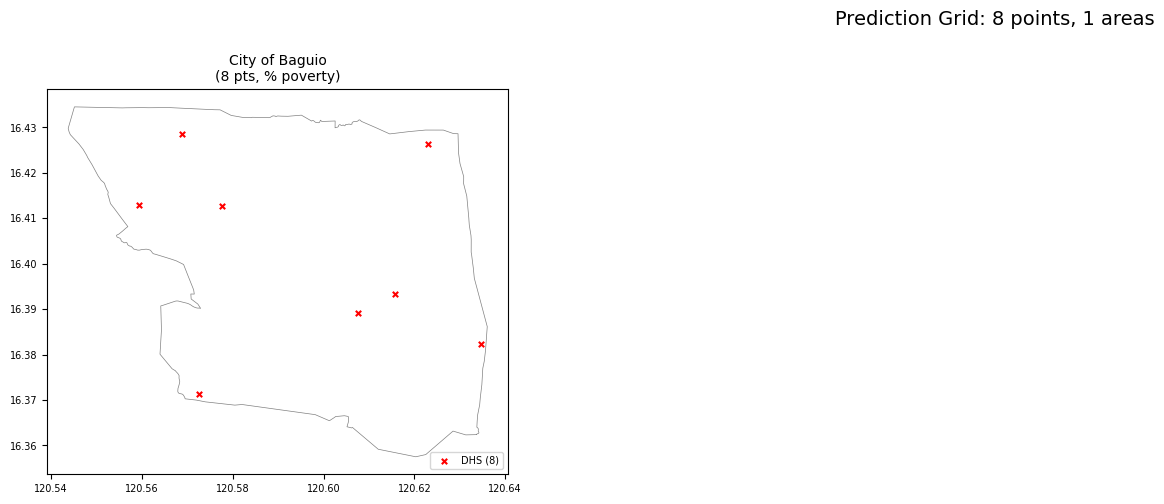

In [13]:
# ============================================================
# 6. QUICK MAP
# ============================================================

import matplotlib.pyplot as plt

provinces = sorted(gdf_out['Province'].unique())
n_prov = len(provinces)
ncols = 4
nrows = (n_prov + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, prov in enumerate(provinces):
    ax = axes[i]
    prov_bounds = gdf_target[gdf_target[COL_PROVINCE] == prov].to_crs('EPSG:4326')
    prov_bounds.boundary.plot(ax=ax, color='gray', linewidth=0.5)

    pts = gdf_out[gdf_out['Province'] == prov]
    grid_pts = pts[pts['source'] == 'grid']
    dhs_pts = pts[pts['source'] == 'DHS']

    if len(grid_pts) > 0:
        ax.scatter(grid_pts['Longitude'], grid_pts['Latitude'],
                   s=3, c='steelblue', alpha=0.6, label=f'Grid ({len(grid_pts)})')
    if len(dhs_pts) > 0:
        ax.scatter(dhs_pts['Longitude'], dhs_pts['Latitude'],
                   s=15, c='red', marker='x', label=f'DHS ({len(dhs_pts)})')

    poverty = POVERTY_RATES.get(prov, '')
    ax.set_title(f"{prov}\n({len(pts)} pts, {poverty}% poverty)", fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Prediction Grid: {len(gdf_out)} points, {n_prov} areas', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/prediction_grid_overview.png', dpi=150, bbox_inches='tight')
plt.show()